# Setup

Questo progetto richiede Python 3.10 o superiore:

In [1]:
import sys

assert sys.version_info >= (3, 10)

Richiede anche Scikit-Learn ≥ 1.6.1:

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Come nei capitoli precedenti, definiamo le dimensioni predefinite dei font per rendere le figure più leggibili:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Scaricare il dataset da Kaggle e importare le librerie

In [5]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("likithagedipudi/cupids-algorithm")

print("Path to dataset files:", path)
print("Archivos:", os.listdir(path))
archivio = os.listdir(path)
csv_path = os.path.join(path, archivio[0])

100%|██████████| 4.02M/4.02M [00:01<00:00, 2.78MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/likithagedipudi/cupids-algorithm/versions/1
Archivos: ['cupid_algorithm_dataset.csv']


Creare il data set

In [6]:
df = pd.read_csv(csv_path)
df.head()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,...,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,...,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,...,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,...,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,...,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,...,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68


Preparare il train set e il test set

In [7]:
# Cancellare le colonne che vorremo predire o classificare e anche pair_id perche cosí ha suggerito la IA per evitare il leakage
X = df.drop(["pair_id", "compatible", "compatibility_score", "relationship_longevity_months"], axis=1)

# Definizione dei target
y_classificazione = df["compatible"]
y_regressione_1 = df["compatibility_score"]
y_regressione_2 = df["relationship_longevity_months"]

# Esecuzione della regressione MLP
X_train, X_test, y_train, y_test = train_test_split(X, y_regressione_1, test_size=0.2, random_state=42)

X_train.info()
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   a_age                       80000 non-null  int64  
 1   a_education                 80000 non-null  int64  
 2   a_location                  80000 non-null  object 
 3   a_career_field              80000 non-null  object 
 4   a_career_ambition           80000 non-null  float64
 5   a_openness                  80000 non-null  float64
 6   a_extraversion              80000 non-null  float64
 7   a_agreeableness             80000 non-null  float64
 8   a_conscientiousness         80000 non-null  float64
 9   a_chronotype                80000 non-null  float64
 10  a_spontaneity               80000 non-null  float64
 11  a_love_language             80000 non-null  object 
 12  a_emotional_expressiveness  80000 non-null  float64
 13  b_age                       8000

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    "a_age", "a_education", "a_career_ambition",
    "a_openness", "a_extraversion", "a_agreeableness", "a_conscientiousness",
    "a_chronotype", "a_spontaneity", "a_emotional_expressiveness",
    "b_age", "b_education", "b_career_ambition",
    "b_openness", "b_extraversion", "b_agreeableness", "b_conscientiousness",
    "b_chronotype", "b_spontaneity", "b_emotional_expressiveness"
]

cat_features = [
    "a_location", "a_career_field", "a_love_language",
    "b_location", "b_career_field", "b_love_language"
]

preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

Qui definiamo l'MLP per regressione.

```python
hidden_layer_sizes=[50, 50, 50]
```

significa che la rete ha tre hidden layer, ciascuno con 50 neuroni.

```python
early_stopping=True
```

fa sì che Scikit-Learn tenga da parte una porzione del training set come validation set interno e fermi l'addestramento quando la performance di validazione smette di migliorare.

In [9]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[100, 100, 100], early_stopping=True,
                       verbose=True, random_state=42)

In [10]:
pipeline = make_pipeline(preprocessing, mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 204.90170904
Validation score: -0.111758
Iteration 2, loss = 60.24197126
Validation score: -0.028014
Iteration 3, loss = 56.18400033
Validation score: 0.048259
Iteration 4, loss = 49.98433391
Validation score: 0.165873
Iteration 5, loss = 44.61185403
Validation score: 0.237635
Iteration 6, loss = 40.20858188
Validation score: 0.305872
Iteration 7, loss = 38.13446092
Validation score: 0.323738
Iteration 8, loss = 37.11535760
Validation score: 0.329390
Iteration 9, loss = 36.43745232
Validation score: 0.349330
Iteration 10, loss = 35.68749131
Validation score: 0.351981
Iteration 11, loss = 35.01113651
Validation score: 0.365698
Iteration 12, loss = 34.34653294
Validation score: 0.363714
Iteration 13, loss = 34.33193842
Validation score: 0.376092
Iteration 14, loss = 33.84275826
Validation score: 0.365966
Iteration 15, loss = 33.55488144
Validation score: 0.356313
Iteration 16, loss = 33.59294403
Validation score: 0.378275
Iteration 17, loss = 33.19159672
Validation sc

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['a_age', 'a_education',
                                                   'a_career_ambition',
                                                   'a_openness',
                                                   'a_extraversion',
                                                   'a_agreeableness',
                                                   'a_conscientiousness',
                                                   'a_chronotype',
                                                   'a_spontaneity',
                                                   'a_emotional_expressiveness',
                                                   'b_age', 'b_education',
                                                   'b_career_ambition',
                                                   'b_openness',
                                                   'b_extraversion',
                                                   'b_agreeableness',
                                                   'b_conscientiousness',
                                                   'b_chronotype',
                                                   'b_spontaneity',
                                                   'b_emotional_expressiveness']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['a_location',
                                                   'a_career_field',
                                                   'a_love_language',
                                                   'b_location',
                                                   'b_career_field',
                                                   'b_love_language'])])),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=[100, 100, 100],
                              random_state=42, verbose=True))])

## Learning curve del training

La `loss_curve_` mostra come cambia la loss durante l'addestramento.

Idealmente vogliamo vedere una diminuzione progressiva della loss. Con `early_stopping=True`, Scikit-Learn tiene anche una parte del training set come validation set interno e può fermare il training quando il modello smette di migliorare.

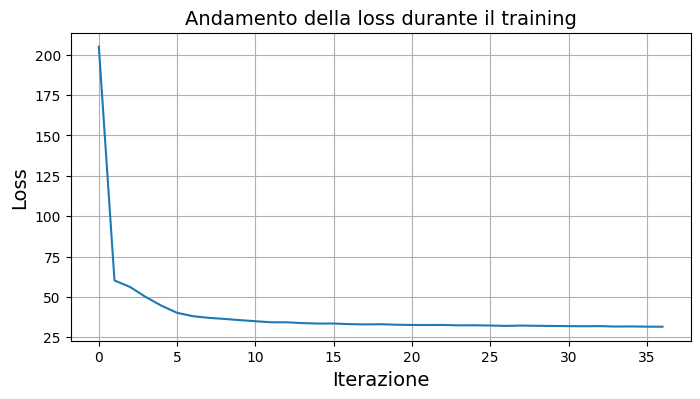

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.loss_curve_)
plt.xlabel("Iterazione")
plt.ylabel("Loss")
plt.title("Andamento della loss durante il training")
plt.grid(True)
plt.show()

## Andamento sul validation set

Con `early_stopping=True`, Scikit-Learn registra anche lo score sul validation set interno.

Questa curva aiuta a capire quando il modello sta migliorando su dati non usati direttamente per aggiornare i pesi.

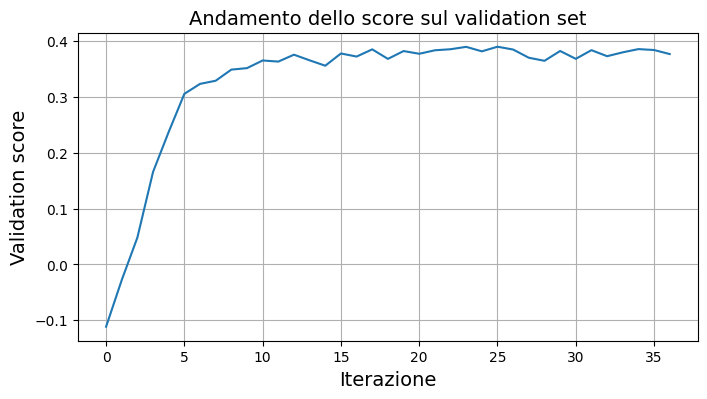

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_reg.validation_scores_)
plt.xlabel("Iterazione")
plt.ylabel("Validation score")
plt.title("Andamento dello score sul validation set")
plt.grid(True)
plt.show()

`best_validation_score_` mostra il miglior punteggio ottenuto sul validation set interno durante l'addestramento.

È utile per capire se l'early stopping ha trovato una configurazione ragionevole prima di valutare il modello sul test set.

In [13]:
mlp_reg.best_validation_score_

0.39037811940914147

Ora valutiamo il modello sul test set usando l'**RMSE**.

L'RMSE è espresso nella stessa unità del target, quindi è più interpretabile del MSE come metrica finale.

In [14]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

8.229927070353236

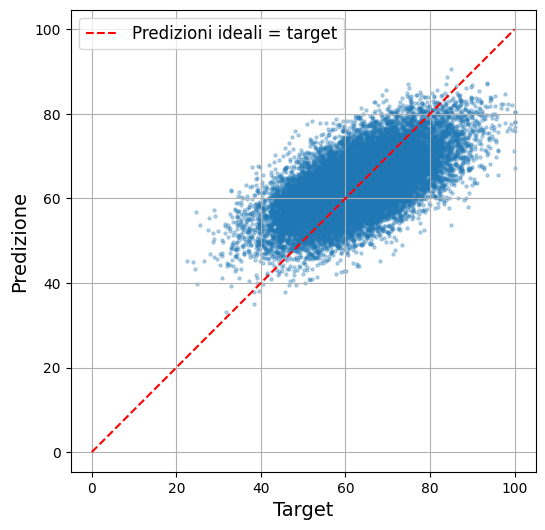

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 100], [0, 100], color='red', linestyle='--',
         label="Predizioni ideali = target")
plt.axis("equal")
plt.xlabel("Target")
plt.ylabel("Predizione")
plt.legend(fontsize=12)
plt.grid()

plt.show()